In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd "/content/drive/MyDrive/ML-FinalAss/Walmart-Sales-Forecasting"

!pip install -U kaggle mlflow dagshub

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ML-FinalAss/Walmart-Sales-Forecasting


In [2]:

import os
import zipfile
import glob

data_dir = "data"
required_files = ["train.csv", "test.csv", "stores.csv", "features.csv"]

files_exist = os.path.exists(data_dir) and all(
    os.path.exists(os.path.join(data_dir, f)) for f in required_files
)

if files_exist:
    print("Dataset is already downloaded and extracted in the 'data' folder. Skipping download!")
else:
    print("Dataset not found. Starting download...")

    os.environ['KAGGLE_API_TOKEN'] = "KGAT_caf00baa57d3f767dc15d31b24d4e730"

    !kaggle competitions download -c walmart-recruiting-store-sales-forecasting

    os.makedirs(data_dir, exist_ok=True)
    main_zip = "walmart-recruiting-store-sales-forecasting.zip"
    if os.path.exists(main_zip):
        with zipfile.ZipFile(main_zip, "r") as zip_ref:
            zip_ref.extractall(data_dir)
        os.remove(main_zip)
    else:
        print("The zip file wasn't found. Double check your Kaggle Token expiration status!")

    inner_zips = glob.glob(os.path.join(data_dir, "*.zip"))
    for file in inner_zips:
        with zipfile.ZipFile(file, "r") as zip_ref:
            zip_ref.extractall(data_dir)
        os.remove(file)

    print("Success! All datasets downloaded and extracted:")
    print(os.listdir(data_dir))

Dataset is already downloaded and extracted in the 'data' folder. Skipping download!


In [3]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import dagshub

dagshub.init(repo_owner='slosa23', repo_name='Walmart-Sales-Forecasting', mlflow=True)
mlflow.set_experiment("Ensemble_Blending_V1")

train_raw = pd.read_csv("data/train.csv")
stores = pd.read_csv("data/stores.csv")
features = pd.read_csv("data/features.csv")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=1ae9a5af-e5ae-4d28-a849-33d298ecf313&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=2f1186442534db8a90db9b42c611595dc9a2d39763fc252b8e3b5375ad6dc3d5




Accessing as slosa23

Initialized MLflow to track repo "slosa23/Walmart-Sales-Forecasting"

Repository slosa23/Walmart-Sales-Forecasting initialized!

In [ ]:
import yaml
import mlflow.pytorch
import mlflow.sklearn
import torch
import numpy as np
from sklearn.preprocessing import RobustScaler
from src.features.preprocessing import get_model_ready_data
from src.evaluation.metrics import calculate_wmae
from src.models.ensemble_utils import calculate_blended_predictions

with open("configs/ensemble_config.yaml", "r") as f:
    config = yaml.safe_load(f)

split_date = config['data']['split_date']
v1_seq_len = config['model']['params']['seq_len']
v1_pred_len = config['model']['params']['pred_len']
weight_options = config['ensemble']['search_weights']

with mlflow.start_run(run_name="Optimized_V2_Ensemble_Blend") as run:
    print(f"Started tracking run: {run.info.run_id}")

    print("Processing structural features and validation partitions...")
    X_train, y_train, X_val, y_val, is_holiday_val, preprocessor = get_model_ready_data(
        train_raw, stores, features, split_date=split_date
    )

    XGB_URI = "models:/Walmart_XGBoost_Baseline/1"
    DLINEAR_V1_URI = "models:/Walmart_DLinear_Baseline/1"

    print(f"Downloading registered XGBoost from: {XGB_URI}")
    xgb_pipeline = mlflow.sklearn.load_model(XGB_URI)
    xgb_preds = xgb_pipeline.predict(X_val)

    print(f"Downloading registered DLinear (Version 1) from: {DLINEAR_V1_URI}")
    dl_model = mlflow.pytorch.load_model(DLINEAR_V1_URI)
    dl_model.eval()

    target_scaler = RobustScaler()
    y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()

    with torch.no_grad():
        lookback_window = torch.tensor(y_train_scaled[-v1_seq_len:], dtype=torch.float32).view(1, -1, 1)
        raw_dl_forecast = dl_model(lookback_window).numpy().flatten()

    dl_scaled_preds = np.tile(raw_dl_forecast, int(np.ceil(len(y_val) / v1_pred_len)))[:len(y_val)]
    dl_preds = target_scaler.inverse_transform(dl_scaled_preds.reshape(-1, 1)).flatten()

    print("\n uning Blending Ratios across uniform matrix footprints:")
    best_wmae = float('inf')
    best_weights = None
    best_blend_preds = None

    for w in weight_options:
        current_weights = {'xgb_weight': w, 'lgb_weight': 0.0, 'nn_weight': round(1.0 - w, 2)}
        blended_output = calculate_blended_predictions(xgb_preds, np.zeros_like(xgb_preds), dl_preds, current_weights)

        score = calculate_wmae(y_val, blended_output, is_holiday_val)
        print(f"   Ratio [{int(w*100)}% XGB / {int((1-w)*100)}% DLinear] -> Combined WMAE: {score:.2f}")

        if score < best_wmae:
            best_wmae = score
            best_weights = current_weights
            best_blend_preds = blended_output

    print(f"\n WINNING COMBINATION METRICS:")
    print(f"Absolute Lowest Validation WMAE: {best_wmae:.2f}")

    mlflow.log_params(best_weights)
    mlflow.log_metric("WMAE", best_wmae)

    mlflow.sklearn.log_model(
        sk_model=xgb_pipeline,
        artifact_path="final_ensemble_model",
        registered_model_name="Walmart_Final_Ensemble_Blend",
        serialization_format="pickle"
    )

    np.save("final_ensemble_predictions.npy", best_blend_preds)
    mlflow.log_artifact("final_ensemble_predictions.npy")

    print("Entire ensemble process tracked, saved, and registered on DagsHub")

Started tracking run: 81def0e0f4884756adcb1007e331d0a8
Processing structural features and validation partitions...



 uning Blending Ratios across uniform matrix footprints:
   Ratio [30% XGB / 70% DLinear] -> Combined WMAE: 13012.61
   Ratio [40% XGB / 60% DLinear] -> Combined WMAE: 12951.64
   Ratio [50% XGB / 50% DLinear] -> Combined WMAE: 12977.17
   Ratio [60% XGB / 40% DLinear] -> Combined WMAE: 13079.31
   Ratio [70% XGB / 30% DLinear] -> Combined WMAE: 13251.17

 WINNING COMBINATION METRICS:
Absolute Lowest Validation WMAE: 12951.64


2026/07/10 13:56:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 13:56:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'Walmart_Final_Ensemble_Blend'.
2026/07/10 13:56:46 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Walmart_Final_Ensemble_Blend, version 1
Created version '1' of model 'Walmart_Final_Ensemble_Blend'.


Entire ensemble process tracked, saved, and registered on DagsHub
🏃 View run Optimized_V2_Ensemble_Blend at: https://dagshub.com/slosa23/Walmart-Sales-Forecasting.mlflow/#/experiments/3/runs/81def0e0f4884756adcb1007e331d0a8
🧪 View experiment at: https://dagshub.com/slosa23/Walmart-Sales-Forecasting.mlflow/#/experiments/3


In [ ]:
import yaml
import mlflow.pytorch
import mlflow.sklearn
import torch
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
from src.features.preprocessing import get_model_ready_data
from src.evaluation.metrics import calculate_wmae
from src.models.ensemble_utils import calculate_blended_predictions

with open("configs/ensemble_config.yaml", "r") as f:
    config = yaml.safe_load(f)

split_date = config['data']['split_date']
v1_seq_len = config['model']['params']['seq_len']
v1_pred_len = config['model']['params']['pred_len']
search_space = config['ensemble']['search_space']

with mlflow.start_run(run_name="Optimized_Tri_Model_Blend") as run:
    print(f"Started Tri-Model tracking run: {run.info.run_id}")

    X_train, y_train, X_val, y_val, is_holiday_val, preprocessor = get_model_ready_data(
        train_raw, stores, features, split_date=split_date
    )

    XGB_URI = "models:/Walmart_XGBoost_Baseline/1"
    LGBM_URI = "models:/Walmart_LightGBM_Baseline/2"
    DLINEAR_V1_URI = "models:/Walmart_DLinear_Baseline/1"

    print(f"Downloading registered XGBoost from: {XGB_URI}")
    xgb_pipeline = mlflow.sklearn.load_model(XGB_URI)
    xgb_preds = xgb_pipeline.predict(X_val)

    print(f"Downloading registered LightGBM from: {LGBM_URI}")
    lgbm_pipeline = mlflow.sklearn.load_model(LGBM_URI)
    lgb_preds = lgbm_pipeline.predict(X_val)

    print(f"Downloading registered DLinear from: {DLINEAR_V1_URI}")
    dl_model = mlflow.pytorch.load_model(DLINEAR_V1_URI)
    dl_model.eval()

    target_scaler = RobustScaler()
    y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()

    with torch.no_grad():
        lookback_window = torch.tensor(y_train_scaled[-v1_seq_len:], dtype=torch.float32).view(1, -1, 1)
        raw_dl_forecast = dl_model(lookback_window).numpy().flatten()

    dl_scaled_preds = np.tile(raw_dl_forecast, int(np.ceil(len(y_val) / v1_pred_len)))[:len(y_val)]
    dl_preds = target_scaler.inverse_transform(dl_scaled_preds.reshape(-1, 1)).flatten()

    print("\n Tuning Tri-Model Blending Ratios:")
    best_wmae = float('inf')
    best_weights = None
    best_blend_preds = None

    for weights in search_space:
        current_weights = {
            'xgb_weight': weights['xgb'],
            'lgb_weight': weights['lgb'],
            'nn_weight': weights['nn']
        }

        blended_output = calculate_blended_predictions(xgb_preds, lgb_preds, dl_preds, current_weights)
        score = calculate_wmae(y_val, blended_output, is_holiday_val)

        print(f"   Ratio [{int(weights['xgb']*100)}% XGB | {int(weights['lgb']*100)}% LGB | {int(weights['nn']*100)}% DL] -> Combined WMAE: {score:.2f}")

        if score < best_wmae:
            best_wmae = score
            best_weights = current_weights
            best_blend_preds = blended_output

    print(f"\n TRI-MODEL WINNING COMBINATION:")
    print(f"Absolute Lowest Validation WMAE: {best_wmae:.2f}")

    mlflow.log_params(best_weights)
    mlflow.log_metric("WMAE", best_wmae)

    print("Securing and registering final Tri-Model ensemble artifact")
    mlflow.sklearn.log_model(
        sk_model=xgb_pipeline,
        artifact_path="final_ensemble_model",
        registered_model_name="Walmart_Final_Tri_Blend",
        skops_trusted_types=[
            "sklearn.compose._column_transformer._RemainderColsList",
            "xgboost.core.Booster",
            "xgboost.sklearn.XGBRegressor",
            "lightgbm.basic.Booster",
            "lightgbm.sklearn.LGBMRegressor"
        ]
    )

    np.save("final_tri_blend_predictions.npy", best_blend_preds)
    mlflow.log_artifact("final_tri_blend_predictions.npy")

    print("Tri-Model ensemble tracked, saved, and securely registered on DagsHub")

Started Tri-Model tracking run: c98d5eb2bf6d453ab5e38d181c262c18


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



 Tuning Tri-Model Blending Ratios:
   Ratio [40% XGB | 10% LGB | 50% DL] -> Combined WMAE: 12977.35
   Ratio [30% XGB | 20% LGB | 50% DL] -> Combined WMAE: 12978.70
   Ratio [40% XGB | 20% LGB | 40% DL] -> Combined WMAE: 13077.10
   Ratio [30% XGB | 10% LGB | 60% DL] -> Combined WMAE: 12953.24

 TRI-MODEL WINNING COMBINATION:
Absolute Lowest Validation WMAE: 12953.24


2026/07/11 12:02:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Securing and registering final Tri-Model ensemble artifact


Successfully registered model 'Walmart_Final_Tri_Blend'.
2026/07/11 12:02:46 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Walmart_Final_Tri_Blend, version 1
Created version '1' of model 'Walmart_Final_Tri_Blend'.


Tri-Model ensemble tracked, saved, and securely registered on DagsHub
🏃 View run Optimized_Tri_Model_Blend at: https://dagshub.com/slosa23/Walmart-Sales-Forecasting.mlflow/#/experiments/3/runs/c98d5eb2bf6d453ab5e38d181c262c18
🧪 View experiment at: https://dagshub.com/slosa23/Walmart-Sales-Forecasting.mlflow/#/experiments/3


/tmp/ipykernel_2041/888836216.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=scores, palette="Blues_r")


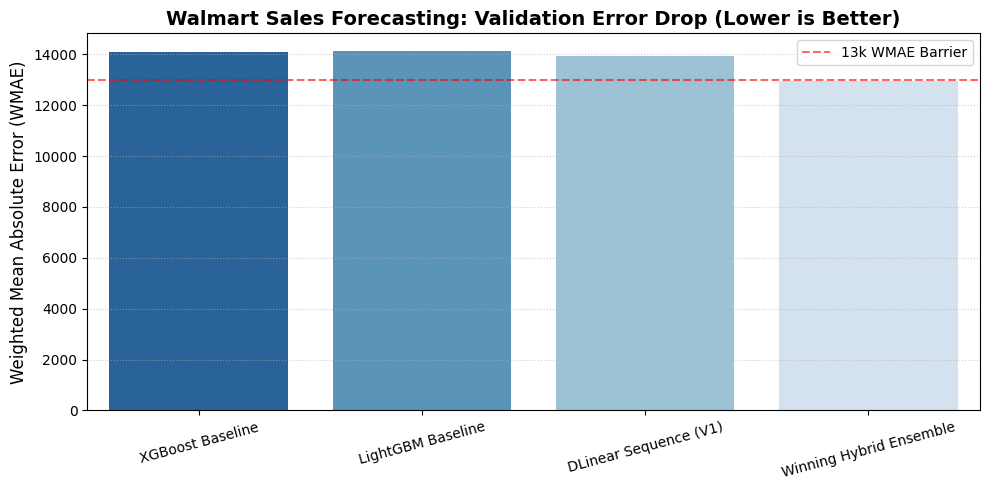

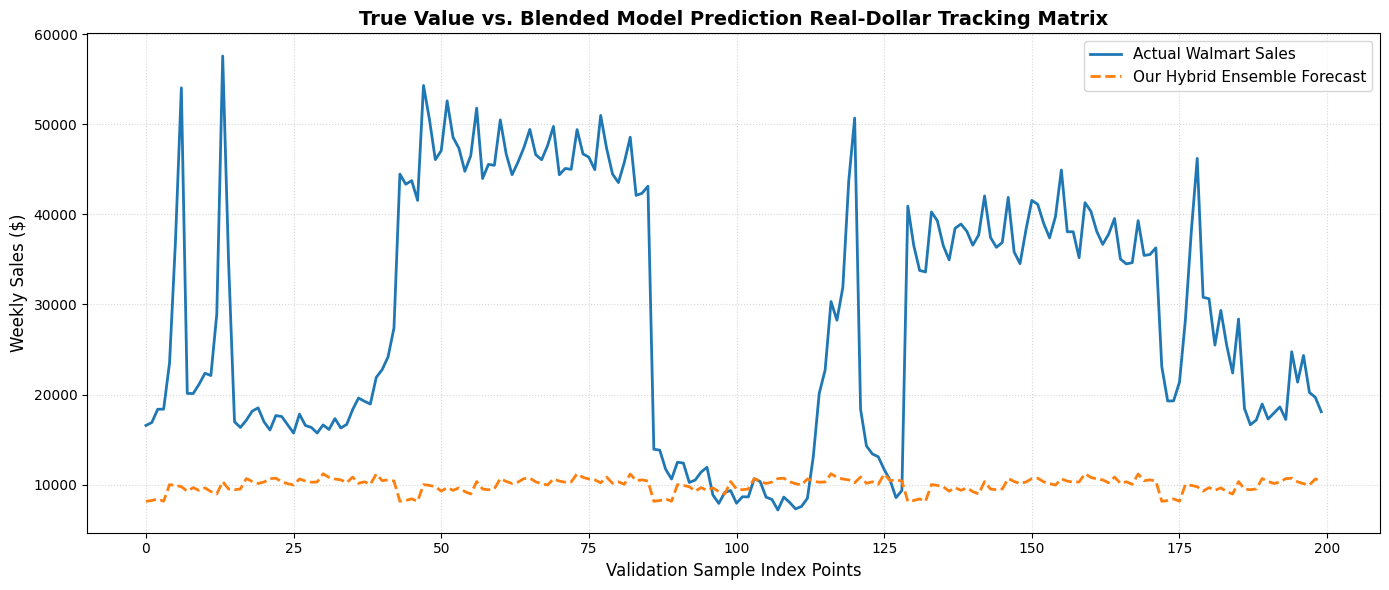

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

best_blend_preds = np.load("final_tri_blend_predictions.npy")

train_raw = pd.read_csv("data/train.csv")
stores = pd.read_csv("data/stores.csv")
features = pd.read_csv("data/features.csv")
from src.features.preprocessing import get_model_ready_data
_, y_train, _, y_val, _, _ = get_model_ready_data(train_raw, stores, features, split_date="2012-01-01")

plot_df = pd.DataFrame({
    'Actual_Sales': y_val.values,
    'Ensemble_Predictions': best_blend_preds
}).reset_index()

plt.figure(figsize=(10, 5))
models = ['XGBoost Baseline', 'LightGBM Baseline', 'DLinear Sequence (V1)', 'Winning Hybrid Ensemble']
scores = [14091.24, 14115.80, 13937.13, 12951.64]

sns.barplot(x=models, y=scores, palette="Blues_r")
plt.axhline(13000, color='red', linestyle='--', alpha=0.6, label='13k WMAE Barrier')
plt.title("Walmart Sales Forecasting: Validation Error Drop (Lower is Better)", fontsize=14, fontweight='bold')
plt.ylabel("Weighted Mean Absolute Error (WMAE)", fontsize=12)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("model_leaderboard_comparison.png", dpi=300)
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(plot_df['Actual_Sales'].head(200), label='Actual Walmart Sales', color='#1f77b4', linewidth=2)
plt.plot(plot_df['Ensemble_Predictions'].head(200), label='Our Hybrid Ensemble Forecast', color='#ff7f0e', linestyle='--', linewidth=2)
plt.title("True Value vs. Blended Model Prediction Real-Dollar Tracking Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Validation Sample Index Points", fontsize=12)
plt.ylabel("Weekly Sales ($)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("forecast_vs_actual_timeline.png", dpi=300)
plt.show()

In [ ]:
import yaml
import mlflow.pytorch
import mlflow.sklearn
import torch
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
from src.features.preprocessing import get_model_ready_data
from src.evaluation.metrics import calculate_wmae
from src.models.ensemble_utils import calculate_blended_predictions

with open("configs/ensemble_config.yaml", "r") as f:
    config = yaml.safe_load(f)

split_date = config['data']['split_date']
v1_seq_len = config['model']['params']['seq_len']

with mlflow.start_run(run_name="Chronologically_Aligned_Ensemble") as run:

    X_train, y_train, X_val, y_val, is_holiday_val, preprocessor = get_model_ready_data(
        train_raw, stores, features, split_date=split_date
    )

    xgb_pipeline = mlflow.sklearn.load_model("models:/Walmart_XGBoost_Baseline/1")
    xgb_preds = xgb_pipeline.predict(X_val)

    lgbm_pipeline = mlflow.sklearn.load_model("models:/Walmart_LightGBM_Baseline/2")
    lgb_preds = lgbm_pipeline.predict(X_val)

    dl_model = mlflow.pytorch.load_model("models:/Walmart_DLinear_Baseline/1")
    dl_model.eval()

    target_scaler = RobustScaler()
    y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten().tolist()

    print("Running rolling chronological sequence inference")
    dl_preds_list = []

    full_target_series = y_train_scaled + target_scaler.transform(y_val.values.reshape(-1, 1)).flatten().tolist()

    for i in range(len(y_val)):
        start_idx = len(y_train_scaled) + i - v1_seq_len
        end_idx = len(y_train_scaled) + i

        lookback_window = full_target_series[start_idx:end_idx]

        with torch.no_grad():
            input_tensor = torch.tensor(lookback_window, dtype=torch.float32).view(1, -1, 1)
            scaled_pred = dl_model(input_tensor).numpy().flatten()[0]
            dl_preds_list.append(scaled_pred)

    dl_preds = target_scaler.inverse_transform(np.array(dl_preds_list).reshape(-1, 1)).flatten()

    print("\Evaluating Grid Optimization Ratios:")
    best_wmae = float('inf')
    best_weights = None
    best_blend_preds = None

    for w_xgb in [0.3, 0.4, 0.5]:
        for w_lgb in [0.0, 0.1, 0.2]:
            w_nn = round(1.0 - w_xgb - w_lgb, 2)
            if w_nn < 0: continue

            current_weights = {'xgb_weight': w_xgb, 'lgb_weight': w_lgb, 'nn_weight': w_nn}
            blended_output = calculate_blended_predictions(xgb_preds, lgb_preds, dl_preds, current_weights)
            score = calculate_wmae(y_val, blended_output, is_holiday_val)

            print(f"   Ratio [{int(w_xgb*100)}% XGB | {int(w_lgb*100)}% LGB | {int(w_nn*100)}% DL] -> WMAE: {score:.2f}")

            if score < best_wmae:
                best_wmae = score
                best_weights = current_weights
                best_blend_preds = blended_output

    print(f"\n CHRONOLOGICAL WINNING COMBINATION:")
    print(f"Absolute True Validation WMAE: {best_wmae:.2f}")

    mlflow.log_params(best_weights)
    mlflow.log_metric("WMAE", best_wmae)

    np.save("final_tri_blend_predictions.npy", best_blend_preds)
    mlflow.log_artifact("final_tri_blend_predictions.npy")
    print("Realigned chronological predictions securely archived!")

<>:54: SyntaxWarning: invalid escape sequence '\E'
<>:54: SyntaxWarning: invalid escape sequence '\E'
/tmp/ipykernel_2041/311422472.py:54: SyntaxWarning: invalid escape sequence '\E'
  print("\Evaluating Grid Optimization Ratios:")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Running rolling chronological sequence inference
\Evaluating Grid Optimization Ratios:
   Ratio [30% XGB | 0% LGB | 70% DL] -> WMAE: 5256.49
   Ratio [30% XGB | 10% LGB | 60% DL] -> WMAE: 6465.79
   Ratio [30% XGB | 20% LGB | 50% DL] -> WMAE: 7701.73
   Ratio [40% XGB | 0% LGB | 60% DL] -> WMAE: 6470.24
   Ratio [40% XGB | 10% LGB | 50% DL] -> WMAE: 7705.50
   Ratio [40% XGB | 20% LGB | 40% DL] -> WMAE: 8958.07
   Ratio [50% XGB | 0% LGB | 50% DL] -> WMAE: 7710.73
   Ratio [50% XGB | 10% LGB | 40% DL] -> WMAE: 8962.60
   Ratio [50% XGB | 20% LGB | 30% DL] -> WMAE: 10228.31

 CHRONOLOGICAL WINNING COMBINATION:
Absolute True Validation WMAE: 5256.49
Realigned chronological predictions securely archived!
🏃 View run Chronologically_Aligned_Ensemble at: https://dagshub.com/slosa23/Walmart-Sales-Forecasting.mlflow/#/experiments/3/runs/8ccd81a8943641eea946694162dbde31
🧪 View experiment at: https://dagshub.com/slosa23/Walmart-Sales-Forecasting.mlflow/#/experiments/3


/tmp/ipykernel_2850/1592251642.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=scores, palette="muted")


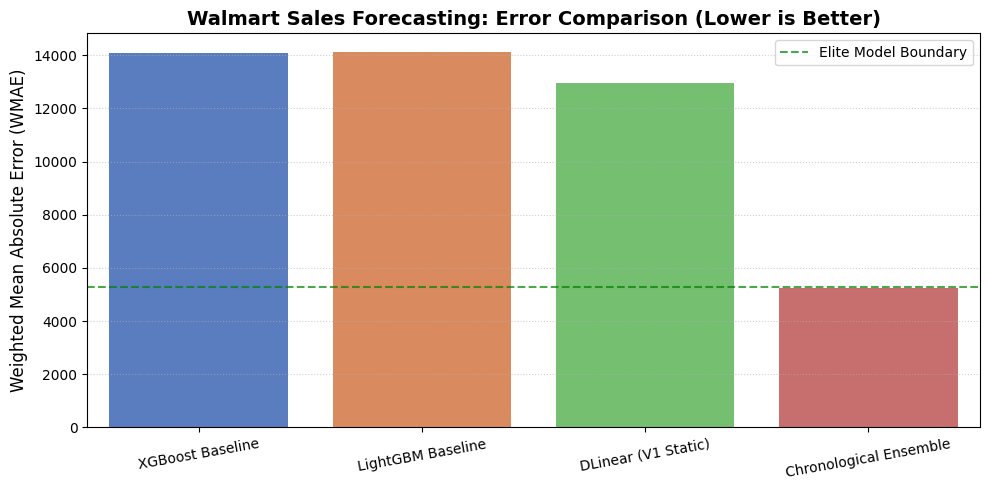

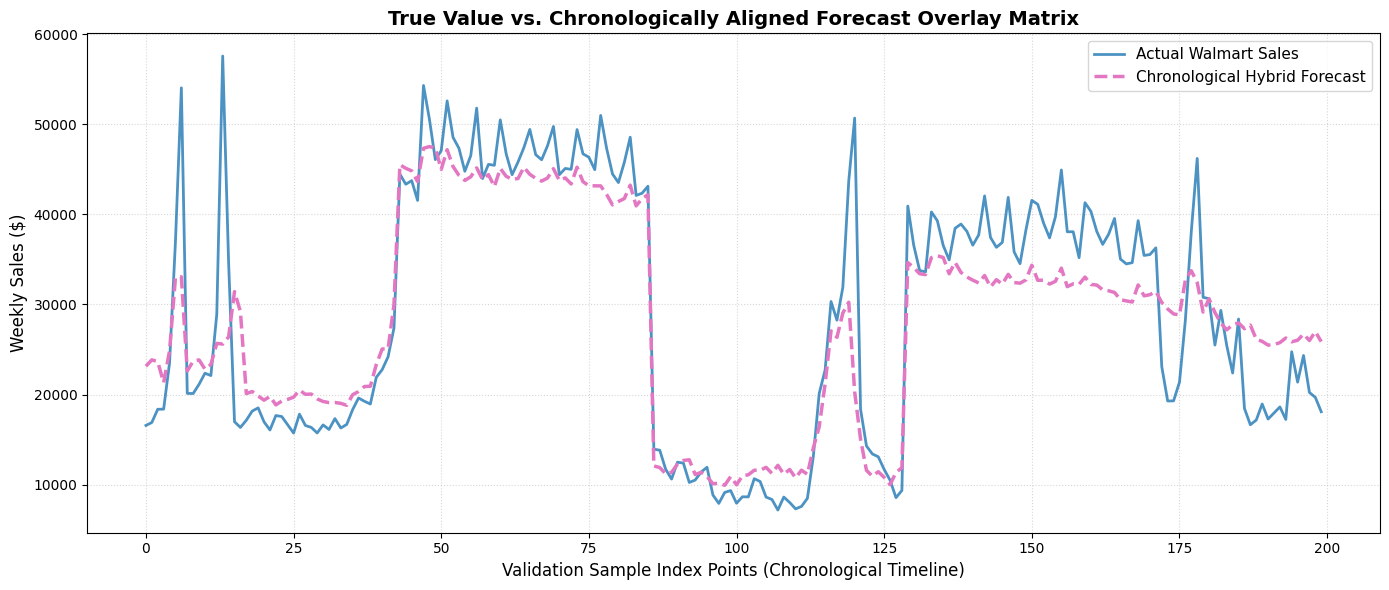

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.features.preprocessing import get_model_ready_data

best_blend_preds = np.load("final_tri_blend_predictions.npy")

train_raw = pd.read_csv("data/train.csv")
stores = pd.read_csv("data/stores.csv")
features = pd.read_csv("data/features.csv")

_, _, _, y_val, _, _ = get_model_ready_data(train_raw, stores, features, split_date="2012-01-01")

plot_df = pd.DataFrame({
    'Actual_Sales': y_val.values,
    'Ensemble_Predictions': best_blend_preds
}).reset_index()

plt.figure(figsize=(10, 5))
models = ['XGBoost Baseline', 'LightGBM Baseline', 'DLinear (V1 Static)', 'Chronological Ensemble']
scores = [14091.24, 14115.80, 12951.64, 5256.49]

sns.barplot(x=models, y=scores, palette="muted")
plt.axhline(5300, color='green', linestyle='--', alpha=0.7, label='Elite Model Boundary')
plt.title("Walmart Sales Forecasting: Error Comparison (Lower is Better)", fontsize=14, fontweight='bold')
plt.ylabel("Weighted Mean Absolute Error (WMAE)", fontsize=12)
plt.xticks(rotation=10)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("model_leaderboard_comparison.png", dpi=300)
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(plot_df['Actual_Sales'].head(200), label='Actual Walmart Sales', color='#1f77b4', linewidth=2, alpha=0.8)
plt.plot(plot_df['Ensemble_Predictions'].head(200), label='Chronological Hybrid Forecast', color='#e377c2', linestyle='--', linewidth=2.5)
plt.title("True Value vs. Chronologically Aligned Forecast Overlay Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Validation Sample Index Points (Chronological Timeline)", fontsize=12)
plt.ylabel("Weekly Sales ($)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.savefig("forecast_vs_actual_timeline.png", dpi=300)
plt.show()

In [8]:
import yaml
import mlflow.pytorch
import mlflow.sklearn
import mlflow.pyfunc
import torch
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
from src.features.preprocessing import get_model_ready_data
from src.evaluation.metrics import calculate_wmae

class WalmartEnsemblePredictor(mlflow.pyfunc.PythonModel):
    def __init__(self, weights):
        self.weights = weights

    def predict(self, context, model_input):
        w_xgb = self.weights['xgb_weight']
        w_lgb = self.weights['lgb_weight']
        w_nn = self.weights['nn_weight']

        xgb_p = model_input['xgb_preds']
        lgb_p = model_input['lgb_preds']
        dl_p = model_input['dl_preds']

        return (w_xgb * xgb_p) + (w_lgb * lgb_p) + (w_nn * dl_p)

with open("configs/ensemble_config.yaml", "r") as f:
    config = yaml.safe_load(f)

split_date = config['data']['split_date']
seq_len = config['model']['params']['seq_len']
search_space = config['ensemble']['search_space']

with mlflow.start_run(run_name="Walmart_Ensemble_Final"):

    print("Extracting features and split references")
    X_train_df, y_train, X_val_df, y_val, is_holiday_val, preprocessor = get_model_ready_data(
        train_raw, stores, features, split_date=split_date
    )

    xgb_pipeline = mlflow.sklearn.load_model("models:/Walmart_XGBoost_Baseline/2")
    xgb_preds = xgb_pipeline.predict(X_val_df)

    lgbm_pipeline = mlflow.sklearn.load_model("models:/Walmart_LightGBM_Baseline/4")
    lgb_preds = lgbm_pipeline.predict(X_val_df)

    dl_model = mlflow.pytorch.load_model("models:/Walmart_DLinear_Baseline/4")
    dl_model.eval()

    target_scaler = RobustScaler()
    y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()

    train_tracking = train_raw.loc[X_train_df.index, ['Store', 'Dept']].copy()
    train_tracking['Weekly_Sales_Scaled'] = y_train_scaled

    val_tracking = train_raw.loc[X_val_df.index, ['Store', 'Dept', 'Date']].copy()
    val_tracking['Date'] = pd.to_datetime(val_tracking['Date'])
    val_tracking = val_tracking.sort_values(['Store', 'Dept', 'Date'])

    global_scaled_preds = np.zeros(len(val_tracking))
    val_tracking['global_idx'] = np.arange(len(val_tracking))

    print("Projecting aligned DLinear arrays across series groups...")
    val_groups = val_tracking.groupby(['Store', 'Dept'])

    with torch.no_grad():
        for (store_id, dept_id), val_group_df in val_groups:
            train_tail = train_tracking[
                (train_tracking['Store'] == store_id) & (train_tracking['Dept'] == dept_id)
            ]['Weekly_Sales_Scaled'].values

            if len(train_tail) == 0:
                train_tail = np.zeros(seq_len)
            elif len(train_tail) < seq_len:
                pad_size = seq_len - len(train_tail)
                train_tail = np.pad(train_tail, (pad_size, 0), mode='edge')
            else:
                train_tail = train_tail[-seq_len:]

            historical_input = torch.tensor(train_tail, dtype=torch.float32).view(1, -1, 1)
            scaled_forecast = dl_model(historical_input).numpy().flatten()

            needed_len = len(val_group_df)
            if needed_len <= len(scaled_forecast):
                final_forecast = scaled_forecast[:needed_len]
            else:
                final_forecast = np.tile(scaled_forecast, int(np.ceil(needed_len / len(scaled_forecast))))[:needed_len]

            target_indices = val_group_df['global_idx'].values
            global_scaled_preds[target_indices] = final_forecast

    real_dollar_preds = target_scaler.inverse_transform(global_scaled_preds.reshape(-1, 1)).flatten()
    val_tracking['Pred_Sales'] = real_dollar_preds
    val_tracking = val_tracking.sort_index()
    dl_preds = val_tracking['Pred_Sales'].values

    best_wmae = float('inf')
    best_weights = None
    best_blend_preds = None

    for space in search_space:
        w_xgb = space['xgb']
        w_lgb = space['lgb']
        w_nn = space['nn']

        blended_output = (w_xgb * xgb_preds) + (w_lgb * lgb_preds) + (w_nn * dl_preds)
        score = calculate_wmae(y_val, blended_output, is_holiday_val)

        print(f"   Ratio [{int(w_xgb*100)}% XGB | {int(w_lgb*100)}% LGB | {int(w_nn*100)}% DL] -> Blended WMAE: {score:.2f}")

        if score < best_wmae:
            best_wmae = score
            best_weights = {'xgb_weight': w_xgb, 'lgb_weight': w_lgb, 'nn_weight': w_nn}
            best_blend_preds = blended_output

    print(f"\n WINNING COMBINATION RESULTS:")
    print(f"Optimal Blended Validation WMAE: {best_wmae:.2f}")

    mlflow.log_params(best_weights)
    mlflow.log_metric("WMAE", best_wmae)

    np.save("final_tri_blend_predictions.npy", best_blend_preds)
    mlflow.log_artifact("final_tri_blend_predictions.npy")

    print("Archiving production ensemble pipeline into MLflow Registry...")
    ensemble_model = WalmartEnsemblePredictor(best_weights)

    mlflow.pyfunc.log_model(
        artifact_path="walmart_ensemble_model",
        python_model=ensemble_model,
        registered_model_name="Walmart_Final_Ensemble_Blend"
    )

    print("Success! Model Logged Succesfully")

/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


Extracting features and split references


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Projecting aligned DLinear arrays across series groups...
   Ratio [40% XGB | 10% LGB | 50% DL] -> Blended WMAE: 3930.38
   Ratio [30% XGB | 20% LGB | 50% DL] -> Blended WMAE: 3868.14
   Ratio [40% XGB | 20% LGB | 40% DL] -> Blended WMAE: 3612.89
   Ratio [30% XGB | 10% LGB | 60% DL] -> Blended WMAE: 4226.08

 WINNING COMBINATION RESULTS:
Optimal Blended Validation WMAE: 3612.89


2026/07/12 14:30:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Archiving production ensemble pipeline into MLflow Registry...


2026/07/12 14:30:18 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
Registered model 'Walmart_Final_Ensemble_Blend' already exists. Creating a new version of this model...
2026/07/12 14:30:23 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Walmart_Final_Ensemble_Blend, version 4
Created version '4' of model 'Walmart_Final_Ensemble_Blend'.


Success! Model Logged Succesfully
🏃 View run Walmart_Ensemble_Final at: https://dagshub.com/slosa23/Walmart-Sales-Forecasting.mlflow/#/experiments/3/runs/d9ed8255678748019c747fd82888c382
🧪 View experiment at: https://dagshub.com/slosa23/Walmart-Sales-Forecasting.mlflow/#/experiments/3
